In [18]:
import numpy as np
import pandas as pd
from utils import load_embeddings, load_embeddings_vec, cosine_sim, plot_pca
from gensim.models import Word2Vec, FastText

In [19]:
print("Loading aligned embeddings (MUSE)")
aligned_types = ["w2v", "ft", "glv", "ohe", "tfidf"]
embeddings_aligned = {et: load_embeddings(et) for et in aligned_types}

print("Loading unaligned embeddings (.vec)...")
unaligned_types = ["w2v", "ft", "glv", "ohe", "tfidf"]
embeddings_unaligned = {et: load_embeddings_vec(et) for et in unaligned_types}

print("\nLoading FastText model (for OOV tests)...")
ft_en_model = FastText.load("./embeddings/ft/english_fasttext.model")

print(f"Aligned: {list(embeddings_aligned.keys())}")
print(f"Unaligned: {list(embeddings_unaligned.keys())}")

Loading aligned embeddings (MUSE)
Loading unaligned embeddings (.vec)...

Loading trained models (for OOV tests)...


FileNotFoundError: [Errno 2] No such file or directory: './embeddings/w2v/english_word2vec.model'

In [ ]:
# Synonyms
en_synonyms = [
    ('happy', 'joyful'), ('big', 'large'), ('smart', 'intelligent'), 
    ('fast', 'quick'), ('beautiful', 'pretty'), ('angry', 'furious')
]
fr_synonyms = [
    ('heureux', 'joyeux'), ('grand', 'gros'), ('intelligent', 'brillant'), 
    ('rapide', 'vite'), ('beau', 'joli'), ('furieux', 'enragé')
]

# Antonyms
en_antonyms = [
    ('happy', 'sad'), ('big', 'small'), ('hot', 'cold'), 
    ('good', 'bad'), ('fast', 'slow'), ('light', 'dark')
]
fr_antonyms = [
    ('heureux', 'triste'), ('grand', 'petit'), ('chaud', 'froid'), 
    ('bon', 'mauvais'), ('rapide', 'lent'), ('clair', 'sombre')
]

# Polysemy (English only)
en_polysemy = [
    ('bank', 'money'), ('bank', 'river'),
    ('light', 'dark'), ('light', 'heavy'),
    ('bat', 'baseball'), ('bat', 'animal')
]

# OOV - expanded with common words (OHE/TF-IDF trained on 1700 words)
oov_tests = {
    "base": ["cat", "walk", "run", "play"],
    "derived": ["walking", "running", "playing", "walked"],
    "compound": ["catwalking", "jaywalking", "moonwalking", "sleepwalking"],
    "rare_derived": ["unbelievable", "misconception", "preprocessing", "counterintuitive"]
}

In [ ]:
def compute_avg_sim(word_pairs, emb, lang1='en', lang2='en'):
    """Compute average similarity, filtering None values"""
    sims = [cosine_sim(w1, w2, emb, lang1, lang2) for w1, w2 in word_pairs]
    valid = [s for s in sims if s is not None]
    return np.mean(valid) if valid else None

In [ ]:
results = []

# Aligned
for emb_type in aligned_types:
    emb = embeddings_aligned[emb_type]
    results.append({
        'Type': 'Aligned',
        'Model': emb_type.upper(),
        'EN_Syn': f"{compute_avg_sim(en_synonyms, emb, 'en', 'en'):.3f}",
        'EN_Ant': f"{compute_avg_sim(en_antonyms, emb, 'en', 'en'):.3f}",
        'FR_Syn': f"{compute_avg_sim(fr_synonyms, emb, 'fr', 'fr'):.3f}",
        'FR_Ant': f"{compute_avg_sim(fr_antonyms, emb, 'fr', 'fr'):.3f}"
    })

# Unaligned
for emb_type in unaligned_types:
    emb = embeddings_unaligned[emb_type]
    en_syn = compute_avg_sim(en_synonyms, emb, 'en', 'en')
    en_ant = compute_avg_sim(en_antonyms, emb, 'en', 'en')
    fr_syn = compute_avg_sim(fr_synonyms, emb, 'fr', 'fr')
    fr_ant = compute_avg_sim(fr_antonyms, emb, 'fr', 'fr')
    
    results.append({
        'Type': 'Unaligned',
        'Model': emb_type.upper(),
        'EN_Syn': f"{en_syn:.3f}" if en_syn else "N/A",
        'EN_Ant': f"{en_ant:.3f}" if en_ant else "N/A",
        'FR_Syn': f"{fr_syn:.3f}" if fr_syn else "N/A",
        'FR_Ant': f"{fr_ant:.3f}" if fr_ant else "N/A"
    })

syn_ant_df = pd.DataFrame(results)
print("SYNONYMS vs ANTONYMS")
syn_ant_df

SYNONYMS vs ANTONYMS


,Type,Model,EN_Syn,EN_Ant,FR_Syn,FR_Ant
0,Aligned,W2V,0.995,0.992,0.993,0.989
1,Aligned,FT,0.999,0.989,0.999,0.966
2,Aligned,GLV,0.153,0.319,0.168,0.277
3,Aligned,OHE,0.000,-0.000,0.000,0.000
4,Aligned,TFIDF,-0.000,0.000,0.000,0.000
5,Unaligned,W2V,0.995,0.992,0.993,0.989
6,Unaligned,FT,0.999,0.989,0.999,0.966
7,Unaligned,GLV,0.153,0.319,0.168,0.277
8,Unaligned,OHE,N/A,N/A,N/A,N/A
9,Unaligned,TFIDF,N/A,N/A,N/A,N/A


In [ ]:
polysemy_results = []

for emb_type in unaligned_types:
    emb = embeddings_unaligned[emb_type]
    avg_sim = compute_avg_sim(en_polysemy, emb, 'en', 'en')
    polysemy_results.append({
        'Type': 'Unaligned',
        'Model': emb_type.upper(),
        'Avg_Similarity': f"{avg_sim:.3f}" if avg_sim else "N/A"
    })

polysemy_df = pd.DataFrame(polysemy_results)
print("\nPOLYSEMY (ambiguous word pairs)")
polysemy_df


POLYSEMY (ambiguous word pairs)


,Type,Model,Avg_Similarity
0,Unaligned,W2V,0.984
1,Unaligned,FT,0.996
2,Unaligned,GLV,0.134
3,Unaligned,OHE,N/A
4,Unaligned,TFIDF,N/A


In [ ]:
test_words = ["cat", "walking", "preprocessing", "sleepwalking"]

vocab_coverage = []

for w in test_words:
    # Check vocabulary presence (static .vec embeddings)
    in_w2v = w in embeddings_unaligned["w2v"]["en"]["words"]
    in_ft = w in embeddings_unaligned["ft"]["en"]["words"]
    in_glv = w in embeddings_unaligned["glv"]["en"]["words"]
    
    # FastText model can generate vectors for OOV words via subwords
    try:
        vec_ft = ft_en_model.wv.get_vector(w)
        ft_model_ok = True
    except KeyError:
        ft_model_ok = False
    
    vocab_coverage.append({
        'Word': w,
        'W2V_vocab': in_w2v,
        'FT_vocab': in_ft,
        'GLV_vocab': in_glv,
        'FT_model': ft_model_ok
    })

vocab_df = pd.DataFrame(vocab_coverage)
vocab_df

In [ ]:
def count_found_words(words, emb, lang='en'):
    """Count how many words are found in vocabulary"""
    return sum(1 for w in words if cosine_sim(w, w, emb, lang, lang) is not None)

def count_ft_model_words(words, model):
    """Count how many words FastText model can handle (including OOV)"""
    count = 0
    for w in words:
        try:
            model.wv.get_vector(w)
            count += 1
        except KeyError:
            pass
    return count


OOV HANDLING (n-gram capability)


,Type,Model,Base,Derived,Compound,Rare Derived
0,Unaligned,W2V,4/4,4/4,0/4,0/4
1,Unaligned,FT,4/4,4/4,0/4,0/4
2,Unaligned,GLV,4/4,4/4,1/4,1/4
3,Unaligned,OHE,4/4,4/4,0/4,0/4
4,Unaligned,TFIDF,4/4,4/4,0/4,0/4


In [ ]:
oov_results = []

for emb_type in unaligned_types:
    emb = embeddings_unaligned[emb_type]
    row = {
        'Type': 'Unaligned',
        'Model': emb_type.upper()
    }
    for category, words in oov_tests.items():
        found = count_found_words(words, emb, 'en')
        row[category.replace('_', ' ').title()] = f"{found}/{len(words)}"
    oov_results.append(row)

# Add FastText model row (with OOV capability)
ft_model_row = {
    'Type': 'FT Model',
    'Model': 'FT (OOV)'
}
for category, words in oov_tests.items():
    found = count_ft_model_words(words, ft_en_model)
    ft_model_row[category.replace('_', ' ').title()] = f"{found}/{len(words)}"
oov_results.append(ft_model_row)

oov_df = pd.DataFrame(oov_results)
print("\n=== OOV HANDLING (n-gram capability) ===")
oov_df

In [ ]:
translation_pairs = [
    ('cat', 'chat'), ('dog', 'chien'), ('house', 'maison'),
    ('car', 'voiture'), ('book', 'livre'), ('water', 'eau')
]
random_pairs_en = [('cat', 'dog'), ('house', 'car'), ('book', 'water')]

space_results = []

# Aligned - cross-lingual and intra-lingual
for emb_type in aligned_types:
    emb = embeddings_aligned[emb_type]
    cross = compute_avg_sim(translation_pairs, emb, 'en', 'fr')
    intra = compute_avg_sim(random_pairs_en, emb, 'en', 'en')
    
    space_results.append({
        'Type': 'Aligned',
        'Model': emb_type.upper(),
        'Cross-Lingual': f"{cross:.3f}" if cross else "N/A",
        'Intra-Lingual': f"{intra:.3f}" if intra else "N/A"
    })

# Unaligned - only intra-lingual (different spaces)
for emb_type in unaligned_types:
    emb = embeddings_unaligned[emb_type]
    intra = compute_avg_sim(random_pairs_en, emb, 'en', 'en')
    
    space_results.append({
        'Type': 'Unaligned',
        'Model': emb_type.upper(),
        'Cross-Lingual': 'N/A',
        'Intra-Lingual': f"{intra:.3f}" if intra else "N/A"
    })

space_df = pd.DataFrame(space_results)
print("\nCROSS-LINGUAL vs INTRA-LINGUAL SIMILARITY")
space_df


CROSS-LINGUAL vs INTRA-LINGUAL SIMILARITY


,Type,Model,Cross-Lingual,Intra-Lingual
0,Aligned,W2V,0.993,0.998
1,Aligned,FT,0.984,0.994
2,Aligned,GLV,0.531,0.308
3,Aligned,OHE,0.721,0.000
4,Aligned,TFIDF,0.766,-0.000
5,Unaligned,W2V,N/A,0.998
6,Unaligned,FT,N/A,0.994
7,Unaligned,GLV,N/A,0.308
8,Unaligned,OHE,N/A,N/A
9,Unaligned,TFIDF,N/A,N/A


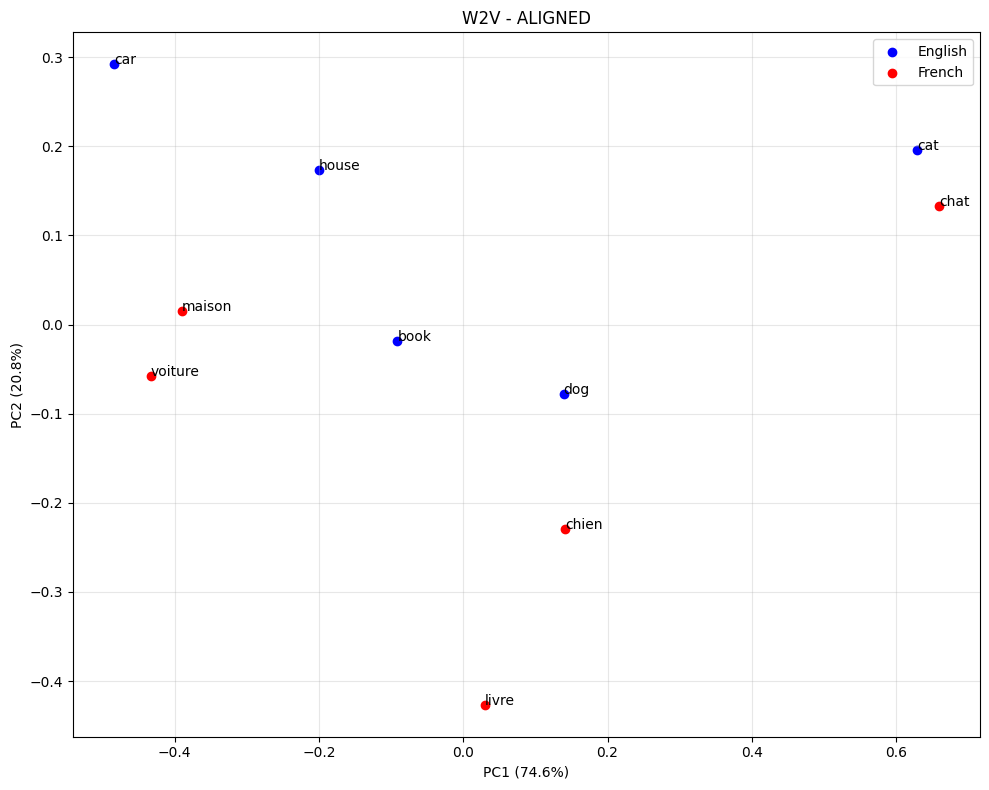

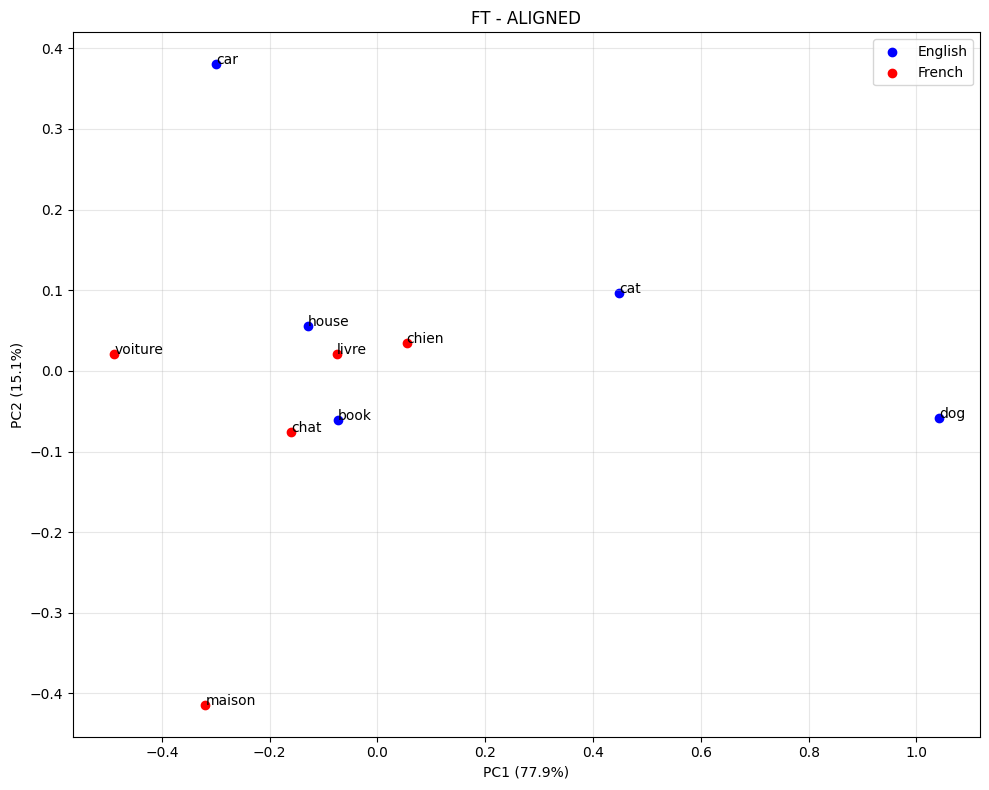

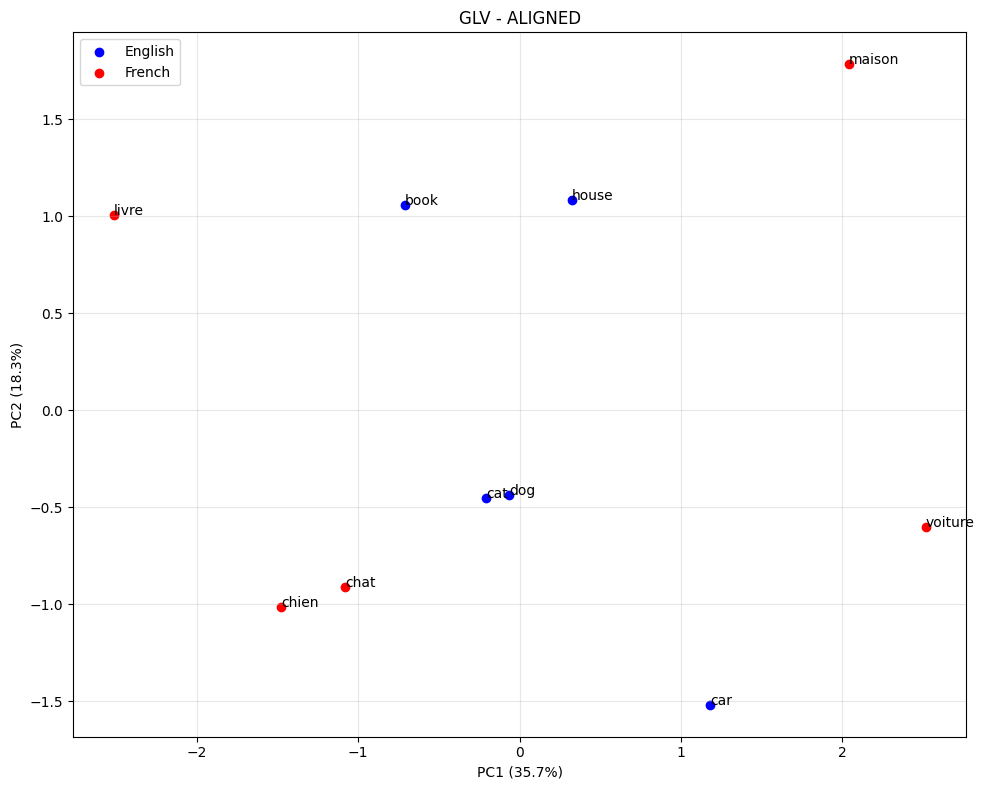

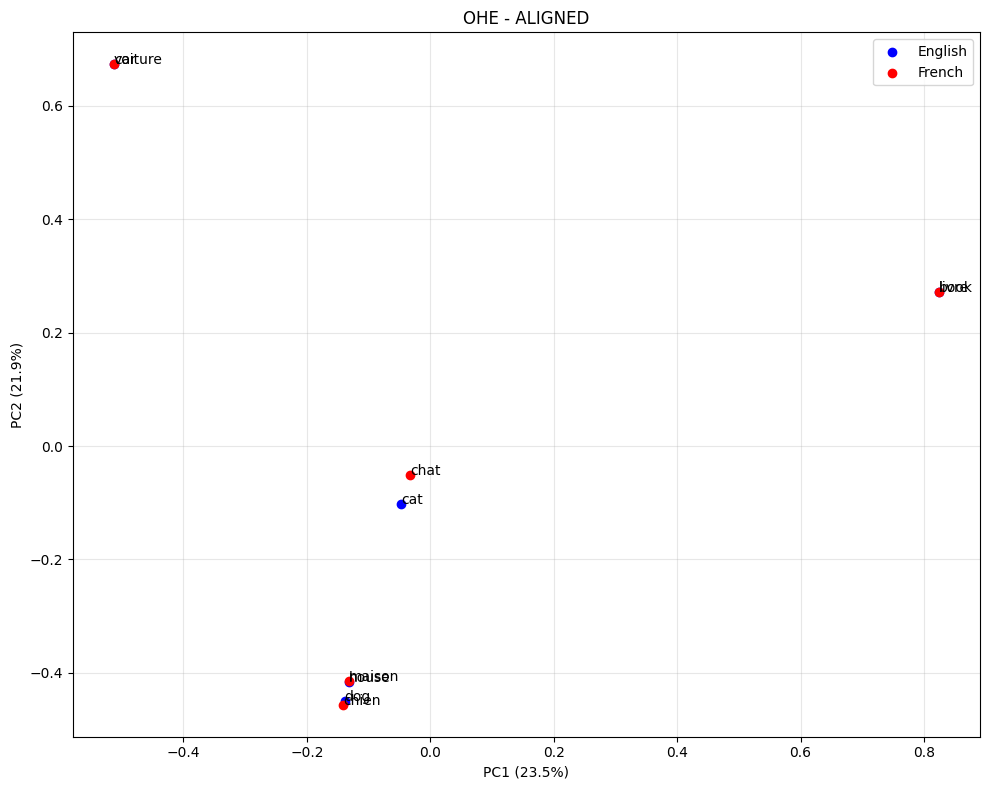

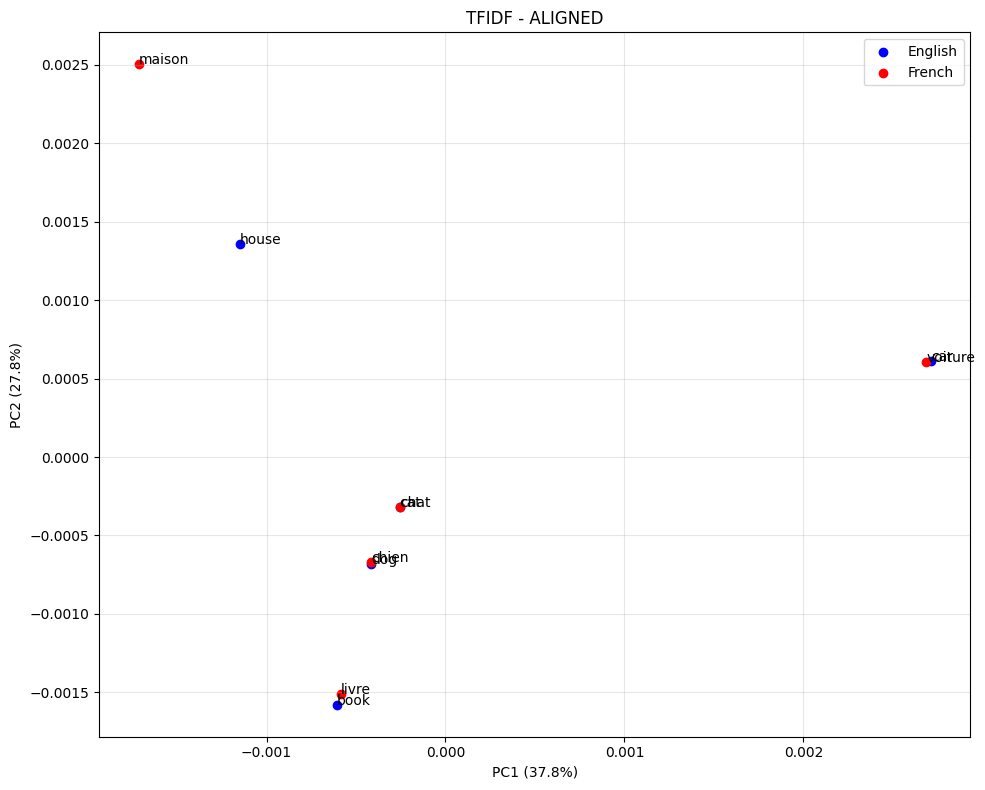

In [ ]:
pairs_pca = [('cat', 'chat'), ('dog', 'chien'), ('house', 'maison'), 
             ('car', 'voiture'), ('book', 'livre')]

for emb_type in aligned_types:
    emb = embeddings_aligned[emb_type]
    plot_pca(emb, pairs_pca, f"{emb_type.upper()} - ALIGNED")